In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
from datetime import timedelta #used to work with time intervals—specifically, to add or subtract days, hours, minutes, etc., from a datetime object.

In [ ]:
# Step 1: Load and prepare the data

# Read the CSV file into a pandas DataFrame
# 'parse_dates' ensures the 'Date' column is converted to datetime objects
# 'dayfirst=True' interprets dates in DD-MM-YYYY format
data = pd.read_csv('/content/stock_data - stock_data.csv', parse_dates=['Date'], dayfirst=True)
print(data.head(3))

# Set the 'Date' column as the index of the DataFrame
# This is useful for time series operations like resampling, rolling averages, etc.
data.set_index('Date', inplace=True)

print(data.head(3))

        Date       Close        High         Low        Open     Volume
0 2022-01-03  178.879913  179.734962  174.653874  174.771805  104487900
1 2022-01-04  176.609650  179.793936  176.039622  179.489270   99310400
2 2022-01-05  171.911865  177.071580  171.636682  176.521213   94537600
                 Close        High         Low        Open     Volume
Date                                                                 
2022-01-03  178.879913  179.734962  174.653874  174.771805  104487900
2022-01-04  176.609650  179.793936  176.039622  179.489270   99310400
2022-01-05  171.911865  177.071580  171.636682  176.521213   94537600


In [ ]:
# Use only the 'Close' column from the DataFrame
close_prices = data['Close'].values  # 1D array
print('Before reshape:', close_prices[0:3])

# Convert it to a NumPy array and reshape it into a 2D array with one column,you get a 2D array with shape (n, 1): (No of rows,1 column)
# This format is required for many machine learning models (e.g., scikit-learn, LSTM)
#-1 tells NumPy to infer the number of rows based on the original size.
#1 sets the number of columns to one—making it a column vector.
close_prices = data['Close'].values.reshape(-1, 1)
print(close_prices[0:3])

print(close_prices.shape)

Before reshape: [178.8799133 176.6096497 171.9118652]
[[178.8799133]
 [176.6096497]
 [171.9118652]]
(501, 1)


In [ ]:
# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)
print(scaled_data[0:3])

[[0.75393208]
 [0.72297868]
 [0.6589278 ]]


In [ ]:
# Step 2: Create sequences for time series modeling
def create_sequences(data, seq_length):
    X, y = [], []  # Initialize empty lists for input sequences (X) and targets (y)

    # Loop through the data starting from 'seq_length' to the end
    for i in range(seq_length, len(data)):
        # Extract a sequence of 'seq_length' values ending at position i
        X.append(data[i-seq_length:i])
        # The target value is the one immediately following the sequence
        y.append(data[i])

    # Convert lists to NumPy arrays for model compatibility
    return np.array(X), np.array(y)

    # Define the sequence length (number of past time steps to use for prediction)
seq_length = 5

# Create input sequences (X) and corresponding target values (y)
# Each X[i] will contain 5 consecutive scaled prices, and y[i] will be the next price

X, y = create_sequences(scaled_data, seq_length)

print('X Value:',X[0:3])
print('y Value:',y[0:3])

#data['Close'].values by itself is a 1D NumPy array with shape (N,) — just a flat vector of closing prices.
#reshape(-1, 1) converts it into a 2D array with shape (N, 1): N = number of rows (days of data), 1 = one column (the closing price feature)
print('Before reshaping X:', X.shape)

# Reshape X to match the input shape expected by LSTM: (samples, time steps, features)
# Here, each sample has 5 time steps and 1 feature (the scaled closing price)
#Let’s say your original scaled_data has 100 rows (i.e., 100 time steps), and your seq_length is 5. Then:
#You can create 100 - 5 = 95 sequences.
#So X.shape[0] will be 95 → meaning 95 rows (or samples).
#After reshaping: X.shape = (95, 5, 1)

X = X.reshape((X.shape[0], X.shape[1], 1))

print('After reshaping X:', X[0:3])
print('After reshaping X:', X.shape)

X Value: [[[0.75393208]
  [0.72297868]
  [0.6589278 ]
  [0.61979999]
  [0.62207785]]

 [[0.72297868]
  [0.6589278 ]
  [0.61979999]
  [0.62207785]
  [0.62234622]]

 [[0.6589278 ]
  [0.61979999]
  [0.62207785]
  [0.62234622]
  [0.66107168]]]
y Value: [[0.62234622]
 [0.66107168]
 [0.66710158]]
Before reshaping X: (496, 5, 1)
After reshaping X: [[[0.75393208]
  [0.72297868]
  [0.6589278 ]
  [0.61979999]
  [0.62207785]]

 [[0.72297868]
  [0.6589278 ]
  [0.61979999]
  [0.62207785]
  [0.62234622]]

 [[0.6589278 ]
  [0.61979999]
  [0.62207785]
  [0.62234622]
  [0.66107168]]]
After reshaping X: (496, 5, 1)


In [ ]:
#Build a RNN (LSTM) model
model = Sequential([
    # First LSTM layer: returns sequences to feed into the next LSTM
    LSTM(128, return_sequences=True, input_shape=(seq_length, 1)),

    # Dropout: randomly drops 30% of units to prevent overfitting
    Dropout(0.5),

    # BatchNormalization: stabilizes and speeds up training
    #BatchNormalization(),

    # Second LSTM layer: returns final output sequence
    LSTM(64, return_sequences=False),

    # Dropout again, but lighter
    Dropout(0.35),

    # Dense layer: adds non-linearity and learns deeper patterns
    Dense(32, activation='relu'),

    # Output layer: predicts the next value
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # What to monitor
    patience=5,             # How many epochs to wait before stopping
    restore_best_weights=True  # Optional: revert to best weights
)

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error',metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X, y, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

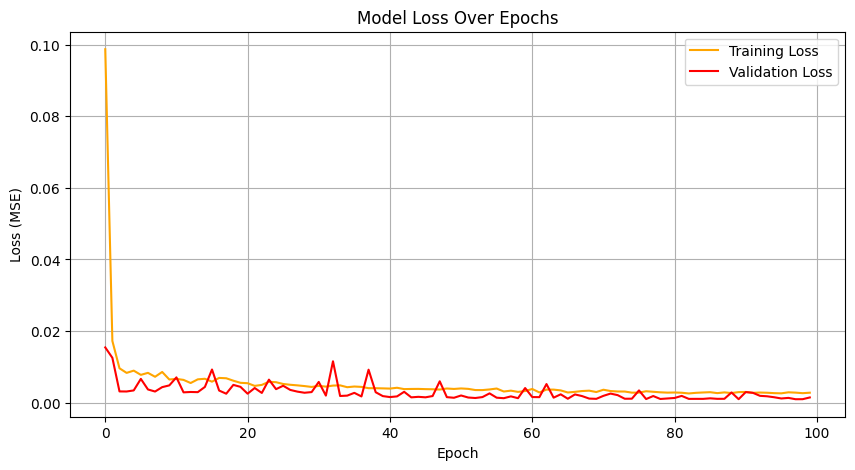

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 5: Predict and inverse transform
predicted_prices = model.predict(X)
predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = scaler.inverse_transform(y)

# Ensure both arrays are the same length
for i in range(10):  # print first 10 comparisons
    print(f"Day {i+1}: Actual = {actual_prices[i][0]:.2f}, Predicted = {predicted_prices[i][0]:.2f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step
Day 1: Actual = 169.23, Predicted = 168.52
Day 2: Actual = 172.07, Predicted = 168.53
Day 3: Actual = 172.51, Predicted = 170.31
Day 4: Actual = 169.23, Predicted = 171.30
Day 5: Actual = 170.09, Predicted = 169.29
Day 6: Actual = 166.88, Predicted = 168.95
Day 7: Actual = 163.37, Predicted = 167.12
Day 8: Actual = 161.68, Predicted = 163.98
Day 9: Actual = 159.62, Predicted = 161.78
Day 10: Actual = 158.84, Predicted = 159.96


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(actual_prices, predicted_prices)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(actual_prices, predicted_prices)
print("MAE:", mae)

from sklearn.metrics import r2_score
r2 = r2_score(actual_prices, predicted_prices)
print("R² Score:", r2)

MSE: 9.707304941505653
RMSE: 3.1156548174510044
MAE: 2.4853729770549164
R² Score: 0.9694826786124054


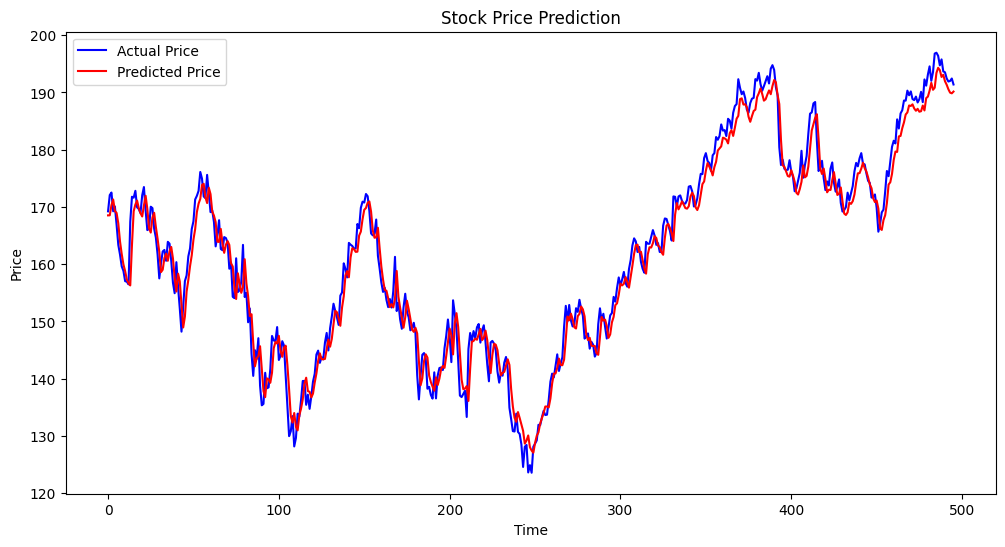

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actual_prices, color='blue', label='Actual Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()